In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

import sys
sys.path.insert(0, '../src')
import utils.visualization as vis
from utils.preprocession import sparsen
from utils.metrics import compute_metric

from models.XPLORE import XPLORE

In [2]:
def show(n=0, q='32214'):
    n = xplore.fit_reactions.index[n]
    fig, (ax1, ax2) = plt.subplots(1,2)

    train_colors = xplore.fit_users.map(candidates.color.to_dict())
    vis.plotEmbedding(xplore.embedding, n=n, c=train_colors, 
                      ax=ax1, highlight={'color':train_colors.loc[n]})

    user = xplore.fit_reactions.loc[n]
    # user.loc[:] = np.NaN
    answers = user.loc[~user.isna()]
    vis.plotObjective(xplore.posterior, answers, d=0, r=xplore.r, area=xplore.area, ax=ax1)

    x, y = xplore.embed(answers)
    ax1.scatter(x, y, marker='x', color='black', s=10, label='Optimized Coordinates', zorder=5)
    _ = ax1.set_title(f'MSE Loss Function for User {n}')

    rgba = vis.colormap(user.astype(float).loc[str(q)])
    vis.plotEmbedding(xplore.embedding, n=n, highlight={'color':rgba},
                    c=xplore.fit_reactions.loc[:,str(q)], ax=ax2)
    vis.plotFeature(xplore.predict, q, d=0, r=xplore.r, area=xplore.area, ax=ax2)
    _ = ax2.set_title(f'Probabilities for Feature {q}')

    print(xplore.fit_rmse, xplore.fit_accuracy)
    return fig


## Load Data

In [3]:
folder_name = '../data'
initial_data = 'candidates_reactions'

candidates   = pd.read_csv(f'{folder_name}/candidates.csv', index_col=0)
ground_truth = pd.read_csv(f'{folder_name}/{initial_data}.csv', index_col=0)
reactions = ground_truth.apply(sparsen, p=.85, axis=1)
reactions

,32214,32215,32216,32217,32218,32219,32220,32221,32222,32223,...,32279,32280,32281,32282,32283,32284,32285,32286,32287,32288
9,NaN,NaN,1.0,NaN,NaN,0.25,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.25,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,1.0,...,NaN,0.83,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,NaN,NaN,NaN,NaN,NaN,0.75,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
31,NaN,NaN,NaN,0.0,NaN,1.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,0.25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5915,NaN,NaN,NaN,NaN,NaN,0.00,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5918,0.75,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,0.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,1.00,NaN,NaN,NaN,0.25,NaN,0.5,NaN,NaN
5922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.00,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN


## Random Initialization Model

In [5]:
xplore = XPLORE(reactions, xmin=-1, xmax=1, resolution=200, 
                test_size=0, prior_cov=np.array([[1, 0], [0, 1]]),
                initialization='random')
xplore.items.head()

,beta1,beta2,alpha
32214,-0.274510,-0.005607,0.344445
32215,-0.247028,-0.088564,-0.534534
32216,0.178764,0.100702,-0.893354
32217,-0.328199,-0.082876,0.036810
32218,0.278085,0.036442,-0.830050


0.37649181972157214 0.6360315160906455


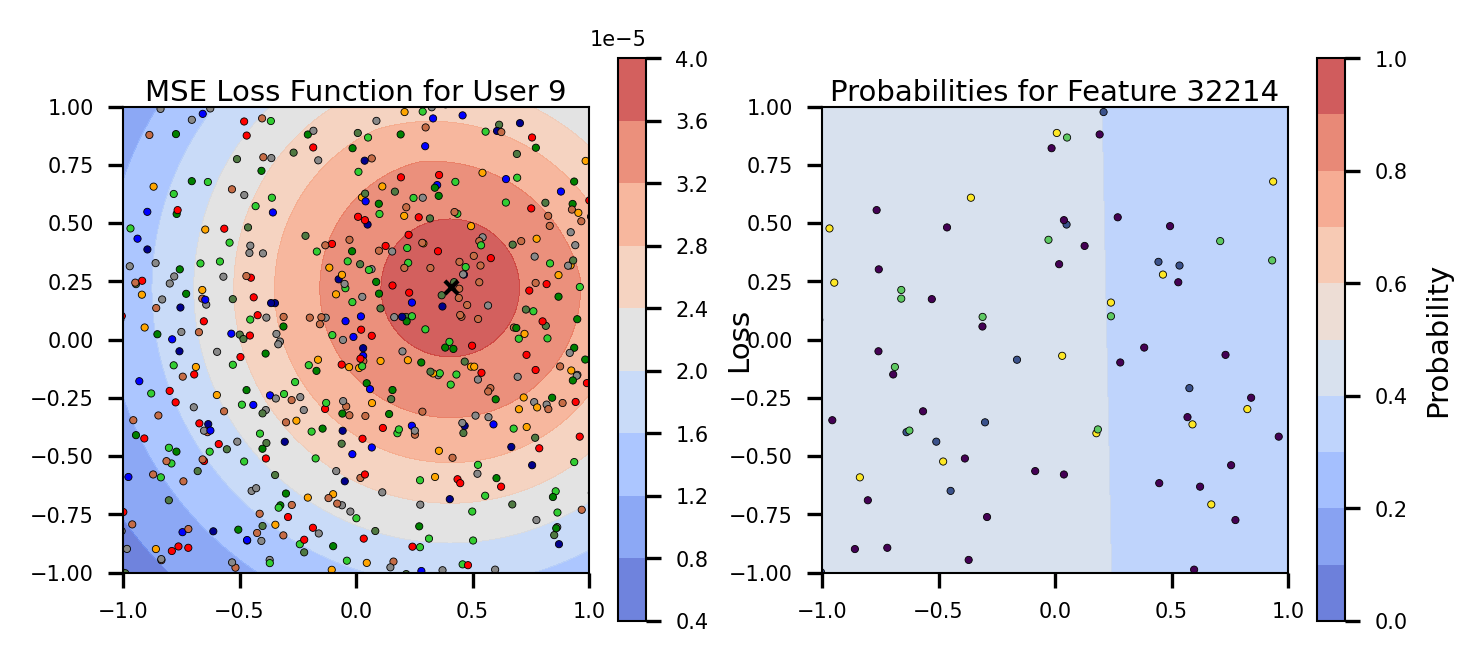

In [6]:
_ = show(n=0)

### Iterations

In [7]:
xplore.fit()

0.35225993907900294 0.6700749685543649
0.3347060670129173 0.657181651045134
0.3235653277196634 0.660228529957315
0.31143190101266977 0.6689567275818729
0.29921076872791397 0.6830089194984812


0.29921076872791397 0.6830089194984812


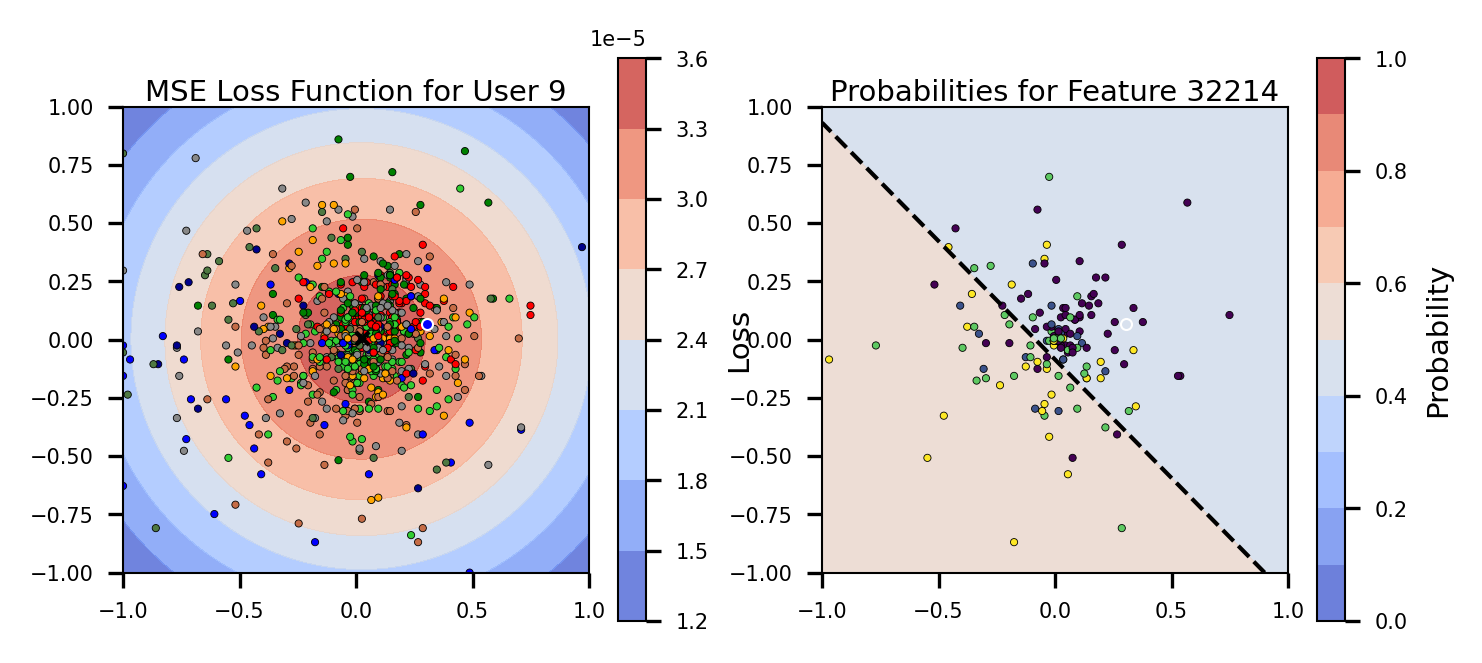

In [8]:
_ = show()

In [9]:
xplore.fit()

0.29443673988143 0.6897654030048528
0.29155035111510624 0.6938960941932201
0.29023555244107796 0.695734168849675
0.28966306066464576 0.6984506751369597
0.28883555931041505 0.698350169071175


### PCA Intitialization

In [4]:
xplore = XPLORE(reactions, xmin=-1, xmax=1, resolution=200, 
                test_size=0, prior_cov=np.array([[1, 0], [0, 1]]),
                initialization='pca')
xplore.items.head()

,beta1,beta2,alpha
32214,2.866551,-7.962542,0.459020
32215,-5.230143,1.651171,-0.915801
32216,0.053385,1.724294,-0.922126
32217,2.192321,-6.705382,0.023457
32218,-6.625901,-0.248366,-1.253544


0.24594385499951701 0.7902613011464308


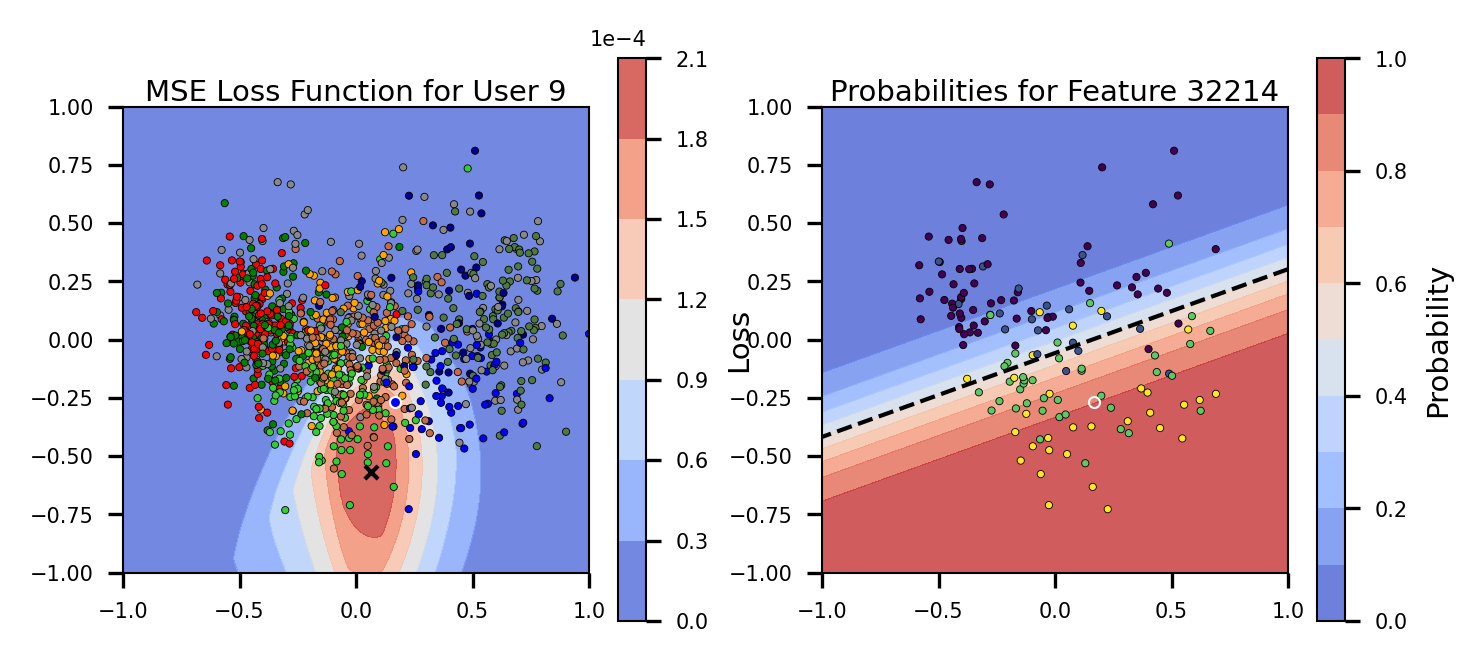

In [5]:
_ = show()

In [6]:
xplore.fit_predictions

,32214,32215,32216,32217,32218,32219,32220,32221,32222,32223,...,32279,32280,32281,32282,32283,32284,32285,32286,32287,32288
9,0.896535,0.402654,0.614603,0.895181,0.555706,0.143800,0.136609,0.297521,0.587634,0.255002,...,0.466439,0.467332,0.183032,0.660652,0.372950,0.558763,0.516278,0.427100,0.671221,0.372705
16,0.026112,0.696152,0.847394,0.061808,0.520012,0.895519,0.458076,0.174426,0.171430,0.838151,...,0.447599,0.707869,0.764586,0.813123,0.608818,0.701985,0.494343,0.771662,0.535557,0.616001
25,0.338409,0.752712,0.720225,0.451622,0.812952,0.727427,0.316953,0.394543,0.272555,0.309454,...,0.333960,0.790692,0.600810,0.774101,0.475439,0.730870,0.393189,0.537439,0.529507,0.630402
30,0.049334,0.984280,0.744663,0.119295,0.993885,0.992510,0.647829,0.810441,0.055277,0.063405,...,0.102442,0.988131,0.958188,0.883880,0.535774,0.926069,0.148852,0.479983,0.270745,0.925223
31,0.140255,0.959686,0.716752,0.255506,0.983207,0.968849,0.518417,0.726198,0.104870,0.084324,...,0.149108,0.969315,0.893500,0.849851,0.498099,0.884803,0.203840,0.464244,0.348480,0.865933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5915,0.561846,0.225078,0.742787,0.616946,0.163917,0.162985,0.162463,0.104553,0.562778,0.782786,...,0.634641,0.246837,0.193314,0.667459,0.466761,0.453038,0.659694,0.648586,0.722751,0.274521
5918,0.702941,0.528209,0.671094,0.743291,0.629099,0.334987,0.197503,0.306218,0.455284,0.324433,...,0.429403,0.585097,0.322372,0.709050,0.421589,0.620825,0.482174,0.492483,0.623528,0.462056
5921,0.694770,0.735050,0.643538,0.745253,0.861762,0.542919,0.242695,0.485285,0.359108,0.146108,...,0.310398,0.786388,0.466144,0.743838,0.411177,0.721427,0.372057,0.422296,0.546887,0.602773
5922,0.062457,0.982220,0.736322,0.142790,0.993256,0.990527,0.626388,0.805575,0.061572,0.061476,...,0.106615,0.986630,0.951148,0.878817,0.526408,0.921611,0.154005,0.469579,0.280697,0.918889


In [9]:
_ = compute_metric(xplore.fit_predictions, ground_truth, reactions.isna())

 Fit Accuracy: 0.8348794063079777
 Fit RMSE: 0.24594385499951701
 Imputation Accuracy: 0.7798681972789115
 Imputation RMSE: 0.2966376902669855



In [10]:
xplore.fit(iter=1, noise=False)


0.23451345862304915 0.8036156283572984


0.23451345862304915 0.8036156283572984


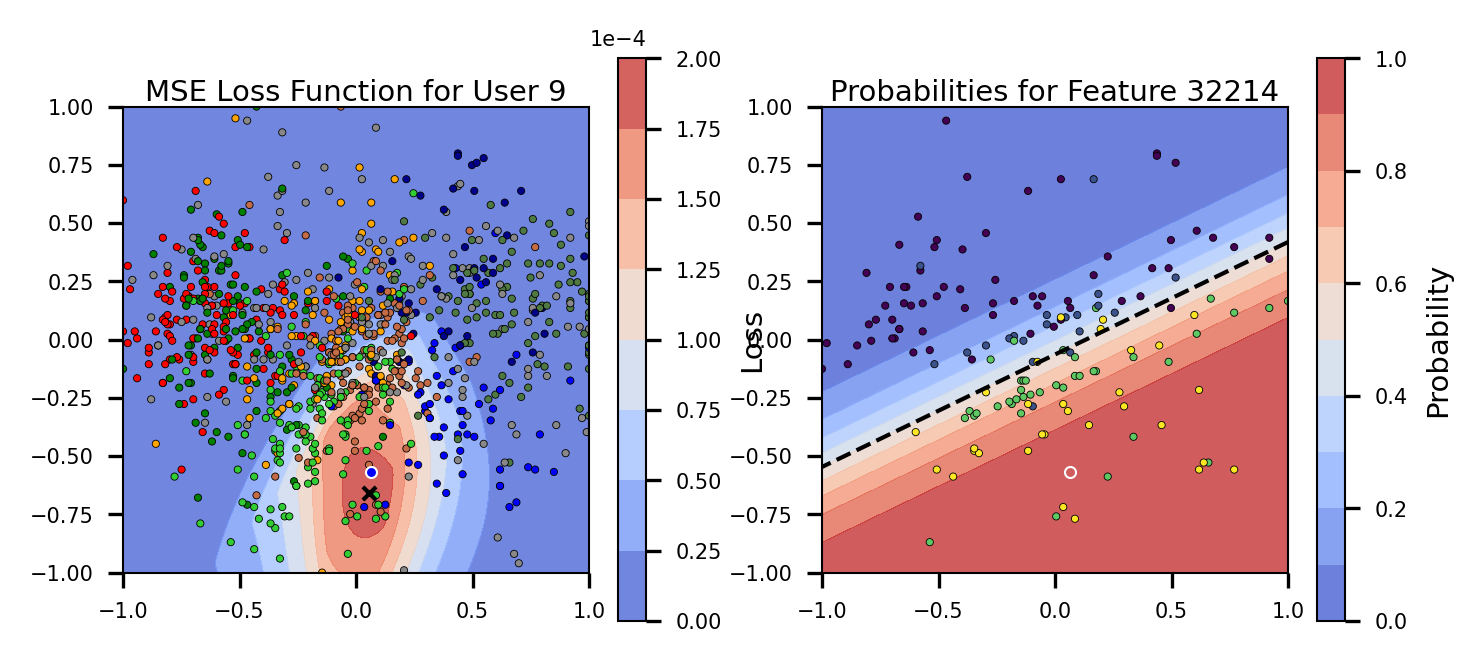

In [11]:
_ = show(n=0)

In [12]:
_ = compute_metric(xplore.fit_predictions, ground_truth, reactions.isna())

 Fit Accuracy: 0.8527255057867302
 Fit RMSE: 0.23451345862304915
 Imputation Accuracy: 0.7790482264334305
 Imputation RMSE: 0.29681396381225217

